In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict

In [3]:
class jokeState(TypedDict):
    topic : str
    joke : str
    explanation : str

In [4]:
llm = ChatOpenAI(model = 'gpt-4o-mini')

In [5]:
def generate_joke(state:jokeState):
    topic = state['topic']
    prompt = f'generate a joke on a following topic {topic}'
    response = llm.invoke(prompt)

    return {'joke':response.content}

In [6]:
def explain_joke(state:jokeState):
    topic = state['topic']
    joke = state['joke']

    prompt = f'give me the explanation of the following joke \n {joke} on the topic {topic}'

    response = llm.invoke(prompt)

    return {'explanation':response.content}

In [7]:
graph = StateGraph(state_schema=jokeState)
graph.add_node('generate_joke',generate_joke)
graph.add_node('explain_joke',explain_joke)

graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','explain_joke')
graph.add_edge('explain_joke',END)

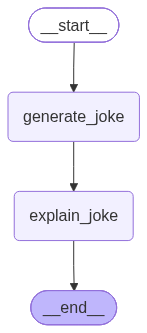

In [8]:
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [9]:
workflow.invoke(input ={
    'topic':'steve smith batting style'
},config = {'configurable':{'thread_id':'session-1'}})

{'topic': 'steve smith batting style',
 'joke': 'Why did Steve Smith bring a ruler to the cricket match? \n\nBecause he wanted to make sure his batting style was always a "measure" above the rest!',
 'explanation': 'This joke plays on a pun involving the word "measure." \n\n1. **Setup**: "Why did Steve Smith bring a ruler to the cricket match?" \n   - Here, we expect a humorous and perhaps absurd reason for bringing an item that\'s not typically associated with cricket.\n\n2. **Punchline**: "Because he wanted to make sure his batting style was always a \'measure\' above the rest!"\n   - The key pun here is on the word "measure." A ruler is used to measure things, but the word can also refer to being "above" in quality or effectiveness compared to others—suggesting that his batting style is superior.\n   - Additionally, Steve Smith is known for his unique and often effective batting technique, so the joke plays on both his skill as a cricketer and the literal usage of a ruler to measure

In [10]:
workflow.get_state(config = {'configurable':{'thread_id':'session-1'}})

StateSnapshot(values={'topic': 'steve smith batting style', 'joke': 'Why did Steve Smith bring a ruler to the cricket match? \n\nBecause he wanted to make sure his batting style was always a "measure" above the rest!', 'explanation': 'This joke plays on a pun involving the word "measure." \n\n1. **Setup**: "Why did Steve Smith bring a ruler to the cricket match?" \n   - Here, we expect a humorous and perhaps absurd reason for bringing an item that\'s not typically associated with cricket.\n\n2. **Punchline**: "Because he wanted to make sure his batting style was always a \'measure\' above the rest!"\n   - The key pun here is on the word "measure." A ruler is used to measure things, but the word can also refer to being "above" in quality or effectiveness compared to others—suggesting that his batting style is superior.\n   - Additionally, Steve Smith is known for his unique and often effective batting technique, so the joke plays on both his skill as a cricketer and the literal usage of

In [11]:
workflow.get_state_history(config= {'configurable':{'thread_id':'session-1'}})

<generator object Pregel.get_state_history at 0x000001FE57603CC0>

In [12]:
list(workflow.get_state_history(config= {'configurable':{'thread_id':'session-1'}}))

[StateSnapshot(values={'topic': 'steve smith batting style', 'joke': 'Why did Steve Smith bring a ruler to the cricket match? \n\nBecause he wanted to make sure his batting style was always a "measure" above the rest!', 'explanation': 'This joke plays on a pun involving the word "measure." \n\n1. **Setup**: "Why did Steve Smith bring a ruler to the cricket match?" \n   - Here, we expect a humorous and perhaps absurd reason for bringing an item that\'s not typically associated with cricket.\n\n2. **Punchline**: "Because he wanted to make sure his batting style was always a \'measure\' above the rest!"\n   - The key pun here is on the word "measure." A ruler is used to measure things, but the word can also refer to being "above" in quality or effectiveness compared to others—suggesting that his batting style is superior.\n   - Additionally, Steve Smith is known for his unique and often effective batting technique, so the joke plays on both his skill as a cricketer and the literal usage o

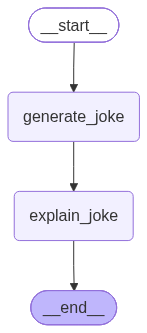

In [13]:
workflow

In [14]:
workflow.invoke({
    'topic':'rohit sharma on the stump mic'
},config = {'configurable':{'thread_id':'session-2'}})

{'topic': 'rohit sharma on the stump mic',
 'joke': 'Why did Rohit Sharma bring a ladder to the stump mic?\n\nBecause he wanted to take his banter to new heights!',
 'explanation': 'This joke plays on a few layers of wordplay and context related to cricket and the personality of Rohit Sharma.\n\n1. **Stump Mic**: In cricket, the stump mic is a microphone placed near the stumps that captures sound from the field, including players\' banter, conversations, and sometimes even humorous exchanges. It\'s a tool that allows fans to hear what players are saying on the field.\n\n2. **Banter**: This refers to playful or teasing remarks exchanged between players. Rohit Sharma, being a prominent cricketer, is often involved in on-field banter, which can be entertaining for fans.\n\n3. **Ladder to New Heights**: The phrase "take his banter to new heights" is a play on words. A ladder is a tool used to reach higher places, so the idea of bringing a ladder suggests Rohit wants to elevate or enhance h

In [15]:
workflow.get_state(config= {'configurable':{'thread_id':'session-2'}})

StateSnapshot(values={'topic': 'rohit sharma on the stump mic', 'joke': 'Why did Rohit Sharma bring a ladder to the stump mic?\n\nBecause he wanted to take his banter to new heights!', 'explanation': 'This joke plays on a few layers of wordplay and context related to cricket and the personality of Rohit Sharma.\n\n1. **Stump Mic**: In cricket, the stump mic is a microphone placed near the stumps that captures sound from the field, including players\' banter, conversations, and sometimes even humorous exchanges. It\'s a tool that allows fans to hear what players are saying on the field.\n\n2. **Banter**: This refers to playful or teasing remarks exchanged between players. Rohit Sharma, being a prominent cricketer, is often involved in on-field banter, which can be entertaining for fans.\n\n3. **Ladder to New Heights**: The phrase "take his banter to new heights" is a play on words. A ladder is a tool used to reach higher places, so the idea of bringing a ladder suggests Rohit wants to e

In [16]:
list(workflow.get_state_history(config= {'configurable':{'thread_id':'session-2'}}))

[StateSnapshot(values={'topic': 'rohit sharma on the stump mic', 'joke': 'Why did Rohit Sharma bring a ladder to the stump mic?\n\nBecause he wanted to take his banter to new heights!', 'explanation': 'This joke plays on a few layers of wordplay and context related to cricket and the personality of Rohit Sharma.\n\n1. **Stump Mic**: In cricket, the stump mic is a microphone placed near the stumps that captures sound from the field, including players\' banter, conversations, and sometimes even humorous exchanges. It\'s a tool that allows fans to hear what players are saying on the field.\n\n2. **Banter**: This refers to playful or teasing remarks exchanged between players. Rohit Sharma, being a prominent cricketer, is often involved in on-field banter, which can be entertaining for fans.\n\n3. **Ladder to New Heights**: The phrase "take his banter to new heights" is a play on words. A ladder is a tool used to reach higher places, so the idea of bringing a ladder suggests Rohit wants to 

## concept of the time travel

In [17]:
workflow.invoke(input = {
    'topic':'rohit sharma and his scolding languages recorded on the stump mic'
},config = {'configurable':{'thread_id':'session-rohit-gali'}})

{'topic': 'rohit sharma and his scolding languages recorded on the stump mic',
 'joke': 'Why did Rohit Sharma bring a ladder to the cricket field? \n\nBecause he heard his stump mic was recording, and he wanted to take his scolding skills to new heights! 😄',
 'explanation': 'This joke plays on a couple of elements related to cricket and Rohit Sharma\'s personality.\n\n1. **Stump Mic**: In cricket, a stump mic is used to capture sounds on the field, including the players’ conversations and any interactions with the umpires. It\'s common for players to express their frustration or to have heated exchanges that can sometimes be heard clearly on broadcasts due to the stump mic.\n\n2. **Scolding Skills**: This part of the joke pokes fun at Rohit Sharma\'s supposed ability to express displeasure or "scold" his teammates or opponents when things aren\'t going well in a match. It implies that he is particularly good or animated when it comes to expressing his feelings, which can often be humor

In [18]:
list(workflow.get_state_history(config = {'configurable':{'thread_id':'session-rohit-gali'}}))

[StateSnapshot(values={'topic': 'rohit sharma and his scolding languages recorded on the stump mic', 'joke': 'Why did Rohit Sharma bring a ladder to the cricket field? \n\nBecause he heard his stump mic was recording, and he wanted to take his scolding skills to new heights! 😄', 'explanation': 'This joke plays on a couple of elements related to cricket and Rohit Sharma\'s personality.\n\n1. **Stump Mic**: In cricket, a stump mic is used to capture sounds on the field, including the players’ conversations and any interactions with the umpires. It\'s common for players to express their frustration or to have heated exchanges that can sometimes be heard clearly on broadcasts due to the stump mic.\n\n2. **Scolding Skills**: This part of the joke pokes fun at Rohit Sharma\'s supposed ability to express displeasure or "scold" his teammates or opponents when things aren\'t going well in a match. It implies that he is particularly good or animated when it comes to expressing his feelings, whic

In [19]:
workflow.get_state(config = {'configurable':{'thread_id':'session-rohit-gali','checkpoint_id': '1f1aab72-a87f-6804-8001-8f91587be13a'}})

StateSnapshot(values={'topic': 'rohit sharma and his scolding languages recorded on the stump mic', 'joke': 'Why did Rohit Sharma bring a ladder to the cricket field? \n\nBecause he heard his stump mic was recording, and he wanted to take his scolding skills to new heights! 😄'}, next=('explain_joke',), config={'configurable': {'thread_id': 'session-rohit-gali', 'checkpoint_id': '1f1aab72-a87f-6804-8001-8f91587be13a'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-09-07T12:25:09.448686+00:00', parent_config={'configurable': {'thread_id': 'session-rohit-gali', 'checkpoint_ns': '', 'checkpoint_id': '1f1aab72-95d5-6e48-8000-6f0db8bef656'}}, tasks=(PregelTask(id='c1a8be94-b6df-0757-89d5-b4fb41179a42', name='explain_joke', path=('__pregel_pull', 'explain_joke'), error=None, interrupts=(), state=None, result={'explanation': 'This joke plays on a couple of elements related to cricket and Rohit Sharma\'s personality.\n\n1. **Stump Mic**: In cricket, a stump mic is use

In [20]:
workflow.invoke(input = None,config = {'configurable':{'thread_id':'session-rohit-gali','checkpoint_id': '1f1aab72-a87f-6804-8001-8f91587be13a'}})

{'topic': 'rohit sharma and his scolding languages recorded on the stump mic',
 'joke': 'Why did Rohit Sharma bring a ladder to the cricket field? \n\nBecause he heard his stump mic was recording, and he wanted to take his scolding skills to new heights! 😄',
 'explanation': "This joke plays on two elements: Rohit Sharma's reputation as a cricket player and his emotional reactions during matches, especially when dealing with difficult situations or players. \n\n1. **Stump Mic**: The stump mic is used in cricket to pick up sounds from the pitch, including players' voices. Occasionally, players can be heard using colorful language or scolding teammates when they’re frustrated. Rohit Sharma, like many cricketers, can get animated during matches, and his vocal reactions can sometimes be entertaining or surprising. \n\n2. **“New Heights”**: The punchline of the joke revolves around the idea of “taking his scolding skills to new heights.” The ladder symbolizes an upward movement, suggesting t

In [21]:
list(workflow.get_state_history(config = {'configurable':{'thread_id':'session-rohit-gali'}}))

[StateSnapshot(values={'topic': 'rohit sharma and his scolding languages recorded on the stump mic', 'joke': 'Why did Rohit Sharma bring a ladder to the cricket field? \n\nBecause he heard his stump mic was recording, and he wanted to take his scolding skills to new heights! 😄', 'explanation': "This joke plays on two elements: Rohit Sharma's reputation as a cricket player and his emotional reactions during matches, especially when dealing with difficult situations or players. \n\n1. **Stump Mic**: The stump mic is used in cricket to pick up sounds from the pitch, including players' voices. Occasionally, players can be heard using colorful language or scolding teammates when they’re frustrated. Rohit Sharma, like many cricketers, can get animated during matches, and his vocal reactions can sometimes be entertaining or surprising. \n\n2. **“New Heights”**: The punchline of the joke revolves around the idea of “taking his scolding skills to new heights.” The ladder symbolizes an upward mo

## Updating State

In [22]:
workflow.update_state(config={'configurable': {'thread_id': 'session-rohit-gali', 'checkpoint_ns': '', 'checkpoint_id': '1f1aab72-95d5-6e48-8000-6f0db8bef656'}},
                      values={'topic':'dhoni bhai and his clamness in the ground'})

{'configurable': {'thread_id': 'session-rohit-gali',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1aab7c-9761-603a-8001-bced9ad9d96a'}}

In [23]:
list(workflow.get_state_history(config = {'configurable':{'thread_id':'session-rohit-gali'}}))

[StateSnapshot(values={'topic': 'dhoni bhai and his clamness in the ground'}, next=('generate_joke',), config={'configurable': {'thread_id': 'session-rohit-gali', 'checkpoint_ns': '', 'checkpoint_id': '1f1aab7c-9761-603a-8001-bced9ad9d96a'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-09-07T12:29:36.089071+00:00', parent_config={'configurable': {'thread_id': 'session-rohit-gali', 'checkpoint_ns': '', 'checkpoint_id': '1f1aab72-95d5-6e48-8000-6f0db8bef656'}}, tasks=(PregelTask(id='fff590c6-7988-2709-d168-f8cb8d4f6e1a', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'rohit sharma and his scolding languages recorded on the stump mic', 'joke': 'Why did Rohit Sharma bring a ladder to the cricket field? \n\nBecause he heard his stump mic was recording, and he wanted to take his scolding skills to new heights! 😄', 'explanation': "This joke plays

In [24]:
workflow.invoke(input = None,config = {'configurable': {'thread_id': 'session-rohit-gali',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1aab7c-9761-603a-8001-bced9ad9d96a'}})

{'topic': 'dhoni bhai and his clamness in the ground',
 'joke': "Why did Dhoni bring a pillow to the cricket match? \n\nBecause he wanted to teach everyone how to stay calm and collected, even when the game's a snooze-fest!",
 'explanation': 'This joke plays on the well-known reputation of Mahendra Singh Dhoni, the former captain of the Indian cricket team, for his calm demeanor on the field, especially under pressure. The humor comes from the playful exaggeration that he would bring a pillow to a cricket match as a metaphor for staying calm and collected, suggesting that he feels relaxed enough to take a nap (hence the pillow) even when the game might be boring or uneventful ("a snooze-fest").\n\nIn essence, the joke highlights Dhoni\'s impressive ability to maintain composure in stressful situations, positioning him as so laid-back that he could literally rest while others might be feeling tense or anxious about the game. It combines admiration for his calmness with a light-hearted t

In [25]:
list(workflow.get_state_history(config = {'configurable':{'thread_id':'session-rohit-gali'}}))

[StateSnapshot(values={'topic': 'dhoni bhai and his clamness in the ground', 'joke': "Why did Dhoni bring a pillow to the cricket match? \n\nBecause he wanted to teach everyone how to stay calm and collected, even when the game's a snooze-fest!", 'explanation': 'This joke plays on the well-known reputation of Mahendra Singh Dhoni, the former captain of the Indian cricket team, for his calm demeanor on the field, especially under pressure. The humor comes from the playful exaggeration that he would bring a pillow to a cricket match as a metaphor for staying calm and collected, suggesting that he feels relaxed enough to take a nap (hence the pillow) even when the game might be boring or uneventful ("a snooze-fest").\n\nIn essence, the joke highlights Dhoni\'s impressive ability to maintain composure in stressful situations, positioning him as so laid-back that he could literally rest while others might be feeling tense or anxious about the game. It combines admiration for his calmness wi

## concept of Fault Tolerance

In [4]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [5]:
    # 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [6]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(1000)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [7]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [ ]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)


In [9]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed

✅ Final State: {'input': 'start', 'step1': 'done', 'step2': 'done'}
